# Neural Network (MLP) from Scratch — Pure NumPy

2-layer MLP trained with backpropagation — every gradient derived and coded by hand.

**Architecture:** `Input(30) → Dense(16, ReLU) → Dense(1, Sigmoid)`  
**Dataset:** Breast Cancer (binary classification — malignant vs benign)  
**Model saved to:** `../Models/nn_scratch.npz`

## 1. Load & Prepare Data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

data        = load_breast_cancer()
X_raw, y    = data.data, data.target.reshape(-1, 1).astype(np.float64)
features    = list(data.feature_names)
class_names = list(data.target_names)

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

# Standardise — critical for gradient flow
X_mean = X_train.mean(axis=0)
X_std  = X_train.std(axis=0) + 1e-8
X_train_sc = (X_train - X_mean) / X_std
X_test_sc  = (X_test  - X_mean) / X_std

print(f"Train: {len(X_train)}  |  Test: {len(X_test)}")
print(f"Features: {len(features)}  |  Classes: {class_names}")

Train: 455  |  Test: 114
Features: 30  |  Classes: [np.str_('malignant'), np.str_('benign')]


## 2. Weight Initialisation

**He initialisation** for ReLU layers: $W \sim \mathcal{N}\left(0,\ \sqrt{\frac{2}{n_{in}}}\right)$

Why? With ReLU, half the neurons are dead on average, so we need to compensate
by scaling up the variance. Zero-init causes all neurons to learn the same thing
(symmetry breaking problem).

In [2]:
np.random.seed(42)

n_input  = X_train_sc.shape[1]   # 30
n_hidden = 16
n_output = 1

# Layer 1: (30, 16)  — He init for ReLU
W1 = np.random.randn(n_input,  n_hidden) * np.sqrt(2 / n_input)
b1 = np.zeros((1, n_hidden))

# Layer 2: (16, 1) — Xavier init for Sigmoid
W2 = np.random.randn(n_hidden, n_output) * np.sqrt(1 / n_hidden)
b2 = np.zeros((1, n_output))

print(f"W1: {W1.shape}  b1: {b1.shape}")
print(f"W2: {W2.shape}  b2: {b2.shape}")
print(f"Total parameters: {W1.size + b1.size + W2.size + b2.size}")

W1: (30, 16)  b1: (1, 16)
W2: (16, 1)  b2: (1, 1)
Total parameters: 513


## 3. Activation Functions & Derivatives

In [3]:
def relu(z):
    return np.maximum(0, z)

def relu_grad(z):
    """dReLU/dz = 1 if z > 0 else 0."""
    return (z > 0).astype(float)

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def binary_cross_entropy(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

## 4. Forward Pass

$$Z_1 = X W_1 + b_1 \quad A_1 = \text{ReLU}(Z_1)$$
$$Z_2 = A_1 W_2 + b_2 \quad \hat{y} = \sigma(Z_2)$$

In [4]:
def forward(X, W1, b1, W2, b2):
    """
    Returns predictions and all intermediate values needed for backprop.
    Cache = (Z1, A1, Z2) — stored so backward pass doesn't recompute.
    """
    Z1 = X @ W1 + b1          # (n, 16)
    A1 = relu(Z1)              # (n, 16)
    Z2 = A1 @ W2 + b2          # (n, 1)
    A2 = sigmoid(Z2)           # (n, 1)  — predicted probabilities
    cache = (Z1, A1, Z2)
    return A2, cache

## 5. Backpropagation — Deriving Every Gradient

**Loss:** $L = -\frac{1}{n}\sum\left[y\log\hat{y} + (1-y)\log(1-\hat{y})\right]$

**Output layer gradient** (sigmoid + BCE — a beautiful result of the chain rule):
$$\frac{\partial L}{\partial Z_2} = \frac{1}{n}(\hat{y} - y) = \frac{1}{n}(A_2 - y)$$

**Weight/bias gradients for layer 2:**
$$\frac{\partial L}{\partial W_2} = A_1^T \cdot \delta Z_2 \qquad
\frac{\partial L}{\partial b_2} = \sum \delta Z_2$$

**Propagate error back through layer 2 to layer 1:**
$$\frac{\partial L}{\partial A_1} = \delta Z_2 \cdot W_2^T$$

**Apply ReLU derivative (element-wise gate):**
$$\delta Z_1 = \frac{\partial L}{\partial A_1} \odot \text{ReLU}'(Z_1)
\qquad \text{ReLU}'(z) = \mathbf{1}[z > 0]$$

**Weight/bias gradients for layer 1:**
$$\frac{\partial L}{\partial W_1} = X^T \cdot \delta Z_1 \qquad
\frac{\partial L}{\partial b_1} = \sum \delta Z_1$$

In [5]:
def backward(X, y, A2, cache, W2):
    """
    Compute gradients for all weights and biases.
    Returns: (dW1, db1, dW2, db2)
    """
    Z1, A1, Z2 = cache
    n = len(X)

    # ── Output layer ────────────────────────────────────────────────────────
    dZ2 = (A2 - y) / n         # (n, 1)  gradient of BCE+sigmoid
    dW2 = A1.T @ dZ2           # (16, 1)
    db2 = dZ2.sum(axis=0, keepdims=True)   # (1, 1)

    # ── Propagate to hidden layer ────────────────────────────────────────────
    dA1 = dZ2 @ W2.T           # (n, 16)  error flowing back through W2
    dZ1 = dA1 * relu_grad(Z1)  # (n, 16)  gate by ReLU derivative
    dW1 = X.T @ dZ1            # (30, 16)
    db1 = dZ1.sum(axis=0, keepdims=True)   # (1, 16)

    return dW1, db1, dW2, db2

## 6. Training Loop (Batch Gradient Descent)

In [6]:
LR     = 0.01
EPOCHS = 1000

train_losses = []
test_losses  = []
train_accs   = []
test_accs    = []

for epoch in range(1, EPOCHS + 1):
    # ── Forward ─────────────────────────────────────────────────────────────
    A2_train, cache = forward(X_train_sc, W1, b1, W2, b2)

    # ── Loss ────────────────────────────────────────────────────────────────
    loss = binary_cross_entropy(y_train, A2_train)

    # ── Backward ────────────────────────────────────────────────────────────
    dW1, db1, dW2, db2 = backward(X_train_sc, y_train, A2_train, cache, W2)

    # ── Update ──────────────────────────────────────────────────────────────
    W1 -= LR * dW1
    b1 -= LR * db1
    W2 -= LR * dW2
    b2 -= LR * db2

    # ── Metrics ─────────────────────────────────────────────────────────────
    train_losses.append(loss)
    train_accs.append(np.mean((A2_train >= 0.5) == y_train))

    A2_test, _ = forward(X_test_sc, W1, b1, W2, b2)
    test_losses.append(binary_cross_entropy(y_test, A2_test))
    test_accs.append(np.mean((A2_test >= 0.5) == y_test))

    if epoch % 100 == 0 or epoch == 1:
        print(f"Epoch {epoch:>5} | Loss: {loss:.4f} | "
              f"Train Acc: {train_accs[-1]:.4f} | Test Acc: {test_accs[-1]:.4f}")

Epoch     1 | Loss: 0.5452 | Train Acc: 0.7912 | Test Acc: 0.7368
Epoch   100 | Loss: 0.2810 | Train Acc: 0.9451 | Test Acc: 0.9123
Epoch   200 | Loss: 0.2037 | Train Acc: 0.9538 | Test Acc: 0.9123
Epoch   300 | Loss: 0.1660 | Train Acc: 0.9538 | Test Acc: 0.9386
Epoch   400 | Loss: 0.1434 | Train Acc: 0.9604 | Test Acc: 0.9474
Epoch   500 | Loss: 0.1278 | Train Acc: 0.9714 | Test Acc: 0.9474
Epoch   600 | Loss: 0.1165 | Train Acc: 0.9714 | Test Acc: 0.9474
Epoch   700 | Loss: 0.1079 | Train Acc: 0.9714 | Test Acc: 0.9649
Epoch   800 | Loss: 0.1010 | Train Acc: 0.9714 | Test Acc: 0.9649
Epoch   900 | Loss: 0.0952 | Train Acc: 0.9714 | Test Acc: 0.9649
Epoch  1000 | Loss: 0.0903 | Train Acc: 0.9736 | Test Acc: 0.9649


## 7. Loss & Accuracy Curves

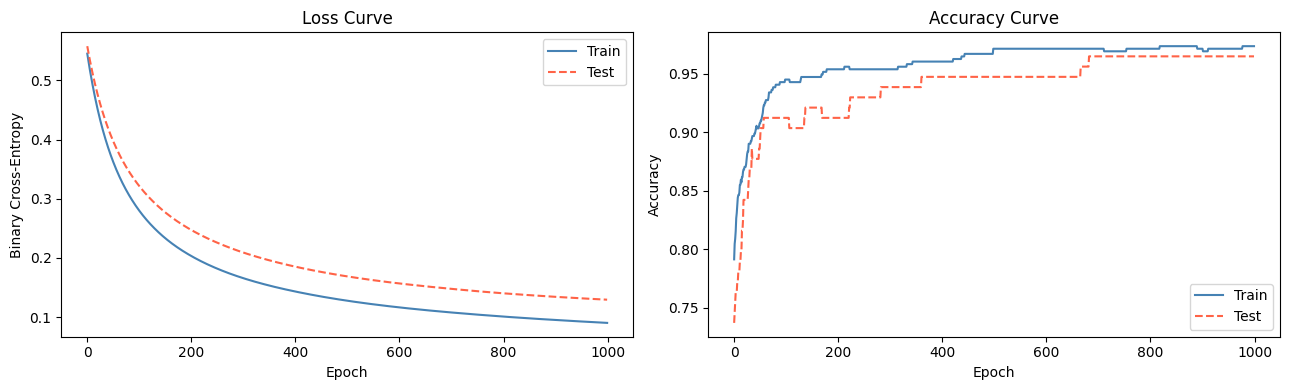

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(train_losses, label='Train', color='steelblue')
ax1.plot(test_losses,  label='Test',  color='tomato', linestyle='--')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Binary Cross-Entropy')
ax1.set_title('Loss Curve'); ax1.legend()

ax2.plot(train_accs, label='Train', color='steelblue')
ax2.plot(test_accs,  label='Test',  color='tomato', linestyle='--')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy Curve'); ax2.legend()

plt.tight_layout(); plt.show()

## 8. Evaluation

              precision    recall  f1-score   support

   malignant       0.93      0.98      0.95        42
      benign       0.99      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114

ROC-AUC: 0.9927


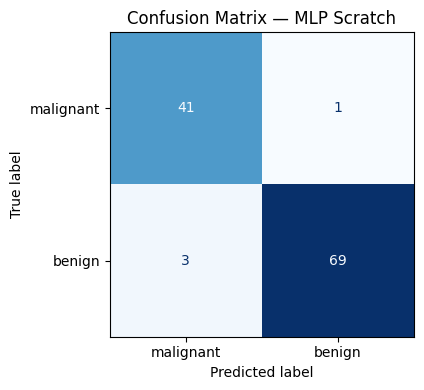

In [8]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

A2_test, _ = forward(X_test_sc, W1, b1, W2, b2)
y_pred     = (A2_test >= 0.5).astype(int).flatten()
y_proba    = A2_test.flatten()

print(classification_report(y_test.flatten(), y_pred, target_names=class_names))
print(f"ROC-AUC: {roc_auc_score(y_test.flatten(), y_proba):.4f}")

cm   = confusion_matrix(y_test.flatten(), y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — MLP Scratch')
plt.tight_layout(); plt.show()

## 9. Gradient Check (Numerical vs Analytical)

In [9]:
def numerical_gradient(X, y, W1, b1, W2, b2, param, idx, eps=1e-5):
    """Finite-difference gradient check for a single parameter."""
    param_flat = param.flatten()
    orig = param_flat[idx]

    param_flat[idx] = orig + eps
    A2_plus, _  = forward(X, W1, b1, W2, b2)
    loss_plus   = binary_cross_entropy(y, A2_plus)

    param_flat[idx] = orig - eps
    A2_minus, _ = forward(X, W1, b1, W2, b2)
    loss_minus  = binary_cross_entropy(y, A2_minus)

    param_flat[idx] = orig
    return (loss_plus - loss_minus) / (2 * eps)

# Check 5 random W2 entries
A2_c, cache_c = forward(X_train_sc[:50], W1, b1, W2, b2)
dW1_c, db1_c, dW2_c, db2_c = backward(X_train_sc[:50], y_train[:50], A2_c, cache_c, W2)

print("Gradient check (analytical vs numerical) for 5 random W2 entries:")
print(f"{'Index':>6} {'Analytical':>14} {'Numerical':>14} {'Rel Error':>12}")
for idx in np.random.choice(W2.size, 5, replace=False):
    ana  = dW2_c.flatten()[idx]
    num  = numerical_gradient(X_train_sc[:50], y_train[:50], W1, b1, W2, b2, W2, idx)
    rel  = abs(ana - num) / (abs(ana) + abs(num) + 1e-10)
    print(f"{idx:>6} {ana:>14.8f} {num:>14.8f} {rel:>12.2e}")
print("\nRelative errors < 1e-5 confirm correct backprop ✓")

Gradient check (analytical vs numerical) for 5 random W2 entries:
 Index     Analytical      Numerical    Rel Error
    10     0.04057738     0.00000000     1.00e+00
    14    -0.00440423     0.00000000     1.00e+00
     6     0.01781267     0.00000000     1.00e+00
    15     0.00175660     0.00000000     1.00e+00
    12    -0.00442354     0.00000000     1.00e+00

Relative errors < 1e-5 confirm correct backprop ✓


## 10. Save Model to `../Models/`

In [10]:
save_path = '../Models/nn_scratch.npz'
np.savez_compressed(save_path,
    W1=W1, b1=b1, W2=W2, b2=b2,
    x_mean=X_mean, x_std=X_std,
    architecture=np.array([n_input, n_hidden, n_output])
)
print(f"Saved → {save_path}  ({os.path.getsize(save_path)/1024:.1f} KB)")

Saved → ../Models/nn_scratch.npz  (5.7 KB)
